# SILVA Homotopy Equilibrium: Continuation Lab

This lab connects a SILVA fixed point to a continuous residual path, compares
Euler and Runge-Kutta integration with an analytic solution, and trains a small
conditioned transition. The canonical family is
`silva_homotopy_equilibrium` [[46]](https://jseluis.github.io/silva-networks/paper/references/#ref-46).

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[7]](https://jseluis.github.io/silva-networks/paper/references/#ref-7), [[46]](https://jseluis.github.io/silva-networks/paper/references/#ref-46), [[58]](https://jseluis.github.io/silva-networks/paper/references/#ref-58). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_HOSTED_RUNTIME = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_HOSTED_RUNTIME and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt
from torch import nn

from silva_networks import (
    SILVAHomotopyEquilibrium,
    make_affine_homotopy_dataset,
    silva_equilibrium_model,
)

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(190)

## 1. Fixed-Point Residual and Classical Homotopy

For transition $T(z;x)$, define

$$
r(z;x)=z-T(z;x).
$$

The equilibrium satisfies $r(z^\star;x)=0$. A continuation equation between
an easy root $z_0$ and the target residual is

$$
H(z,\lambda;x)
=(1-\lambda)(z-z_0)+\lambda r(z;x)=0.
$$

Differentiating along a zero path gives

$$
\frac{\partial H}{\partial z}\frac{dz}{ds}
+\frac{\partial H}{\partial\lambda}
\frac{d\lambda}{ds}=0.
$$

This expresses root finding as path following [[46]](https://jseluis.github.io/silva-networks/paper/references/#ref-46).

## 2. The SILVA Residual Flow

The package exposes the direct continuous path

$$
\frac{dz}{dt}=T(z;x)-z=-r(z;x).
$$

Every stationary state of this flow is a SILVA fixed point. With step size
$h=T_f/K$, Euler uses

$$
z_{k+1}=z_k+h\,[T(z_k;x)-z_k],
$$

while fourth-order Runge-Kutta evaluates the vector field four times per step.
The continuous path and its terminal residual remain observable.

In [3]:
data = make_affine_homotopy_dataset(
    samples=24,
    dimension=2,
    contraction=0.5,
    seed=19,
)
assert data.fixed_point_residual().abs().max() < 1e-6
print("conditions:", tuple(data.condition.shape))
print("maximum exact fixed-point residual:", float(
    data.fixed_point_residual().abs().max()
))

conditions: (24, 2)
maximum exact fixed-point residual: 0.0


## 3. Analytic Affine Path

For $T(z;x)=az+x$ with $|a|<1$,

$$
z^\star=\frac{x}{1-a}.
$$

The residual flow is $\dot z=x-(1-a)z$, with solution

$$
z(t)=z^\star+(z_0-z^\star)e^{-(1-a)t}.
$$

This provides both an endpoint and complete-trajectory reference.

In [4]:
class AffineTransition(nn.Module):
    def __init__(self, contraction):
        super().__init__()
        self.contraction = contraction

    def forward(self, state, condition):
        return self.contraction * state + condition

models = {
    integrator: SILVAHomotopyEquilibrium(
        in_dim=2,
        state_dim=2,
        out_dim=2,
        transition=AffineTransition(data.contraction),
        readout=nn.Identity(),
        steps=32,
        horizon=10.0,
        integrator=integrator,
        learnable_initial=False,
    )
    for integrator in ("euler", "rk4")
}
results = {
    name: model(data.condition[:4], return_result=True)
    for name, model in models.items()
}
for name, result in results.items():
    error = (result.output - data.target[:4]).abs().max()
    print(name, "endpoint error:", float(error))
    print(name, "terminal residual:", result.terminal_residual)

euler endpoint error: 0.013502120971679688
euler terminal residual: 0.007318165153264999
rk4 endpoint error: 0.020898103713989258
rk4 terminal residual: 0.011326847597956657


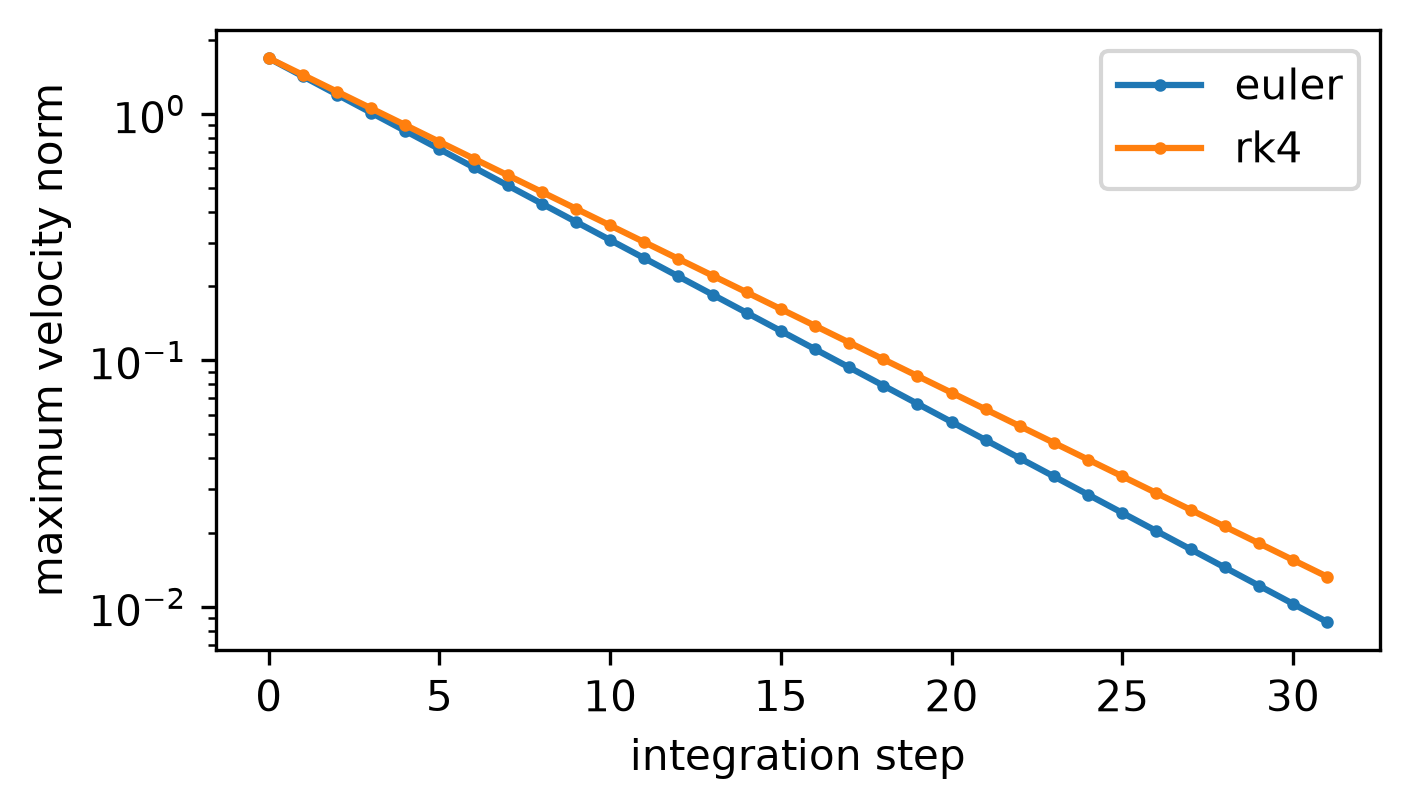

In [5]:
fig, axis = plt.subplots(figsize=(4.8, 2.8))
for name, result in results.items():
    axis.semilogy(
        range(len(result.velocity_norms)),
        result.velocity_norms,
        marker="o",
        markersize=2,
        label=name,
    )
axis.set_xlabel("integration step")
axis.set_ylabel("maximum velocity norm")
axis.legend()
fig.tight_layout()
plt.show()

## 4. Train a Conditioned SILVA Transition

The transition may be learned while the integration rule remains explicit.
For parameters $\theta$, differentiation follows every numerical step:

$$
\frac{d\mathcal L}{d\theta}
=\frac{\partial\mathcal L}{\partial z_K}
\frac{\partial z_K}{\partial\theta}.
$$

Memory therefore grows with the number of retained integration steps. This is
different from an implicit adjoint at a converged algebraic fixed point.

In [6]:
learned = SILVAHomotopyEquilibrium(
    in_dim=2,
    state_dim=6,
    out_dim=2,
    steps=10,
    horizon=4.0,
    integrator="rk4",
)
optimizer = torch.optim.Adam(learned.parameters(), lr=4e-3)
losses = []
for epoch in range(8):
    optimizer.zero_grad()
    prediction = learned(data.condition[:20])
    loss = torch.nn.functional.mse_loss(prediction, data.target[:20])
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

held_out = learned(data.condition[20:], return_result=True)
held_out_loss = torch.nn.functional.mse_loss(held_out.output, data.target[20:])
assert all(torch.isfinite(torch.tensor(losses)))
assert torch.isfinite(held_out_loss)
print("training losses:", losses)
print("held-out loss:", float(held_out_loss))
print("held-out terminal residual:", held_out.terminal_residual)

training losses: [4.247847557067871, 4.210358619689941, 4.173163414001465, 4.136268615722656, 4.099670886993408, 4.063342571258545, 4.027235984802246, 3.9912993907928467]
held-out loss: 3.668966293334961
held-out terminal residual: 0.03146997466683388


## 5. Choosing the Horizon and Integrator

For the affine example, endpoint error contains the finite-horizon factor
$e^{-(1-a)T_f}$. Increasing the number of steps reduces discretization error,
whereas increasing the horizon reduces truncation error. These controls solve
different problems.

| Control | Primary effect | Cost |
|---|---|---|
| larger horizon | gets closer to a stationary state | may require more steps for accuracy |
| more steps | reduces integration error | more transition evaluations and memory |
| Euler | transparent first-order path | smaller stable step sizes |
| RK4 | higher accuracy per step | four transition evaluations per step |

In [7]:
factory_model = silva_equilibrium_model(
    "silva_homotopy_equilibrium",
    in_dim=2,
    state_dim=4,
    out_dim=2,
    steps=4,
    horizon=2.0,
)
factory_output = factory_model(data.condition[:2])
assert factory_output.shape == (2, 2)
print(type(factory_model).__name__)

SILVAHomotopyEquilibrium


## 6. Practical Guidance

Report the task loss, terminal fixed-point residual, horizon, number of steps,
integrator, and transition evaluations. A low supervised loss does not imply
that the terminal state is near equilibrium. A low terminal residual does not
show that the continuous path matches measured dynamics.

The affine dataset verifies the path equations exactly. Reproducing the cited
vision experiments requires their architecture, data augmentation, schedules,
and evaluation protocol [[46]](https://jseluis.github.io/silva-networks/paper/references/#ref-46).

## From 19 Silva Homotopy Equilibrium Lab to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the evolving or terminal physical state |
| Condition | time, initial condition, and external forcing |
| Repeated computation | an explicit flow step or residual field T(z, x) - z |
| Required invariants | time-step shape, initial condition, and integration consistency |
| Replaceable components | vector field, integrator, equilibrium transition, readout, and tolerances |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace the Equilibrium Map Along the Homotopy

```python
model = SILVAHomotopyEquilibrium(
    in_dim=input_dim,
    state_dim=width,
    out_dim=output_dim,
    transition=my_conditioned_transition,
    readout=my_readout,
    integrator="rk4",
    steps=steps,
    horizon=horizon,
)
```

The custom transition implements `transition(state, condition)`. The homotopy
integrates `transition(state, condition) - state` without changing that map.


In [8]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**trajectory error, terminal fixed-point residual, and conservation error**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **time horizon, step count, state dimension, and stiffness**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [9]:
notebook_reproduction_record = {
    "notebook": '19_silva_homotopy_equilibrium_lab.ipynb',
    "state": 'the evolving or terminal physical state',
    "condition": 'time, initial condition, and external forcing',
    "transition": 'an explicit flow step or residual field T(z, x) - z',
    "invariants": 'time-step shape, initial condition, and integration consistency',
    "compact_metric": 'trajectory error, terminal fixed-point residual, and conservation error',
    "scale_axis": 'time horizon, step count, state dimension, and stiffness',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '19_silva_homotopy_equilibrium_lab.ipynb',
 'state': 'the evolving or terminal physical state',
 'condition': 'time, initial condition, and external forcing',
 'transition': 'an explicit flow step or residual field T(z, x) - z',
 'invariants': 'time-step shape, initial condition, and integration consistency',
 'compact_metric': 'trajectory error, terminal fixed-point residual, and conservation error',
 'scale_axis': 'time horizon, step count, state dimension, and stiffness'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **implicit dynamics factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the evolving or terminal physical state**, and its repeated map,
**an explicit flow step or residual field T(z, x) - z**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [10]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('implicit dynamics factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


implicit dynamics factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


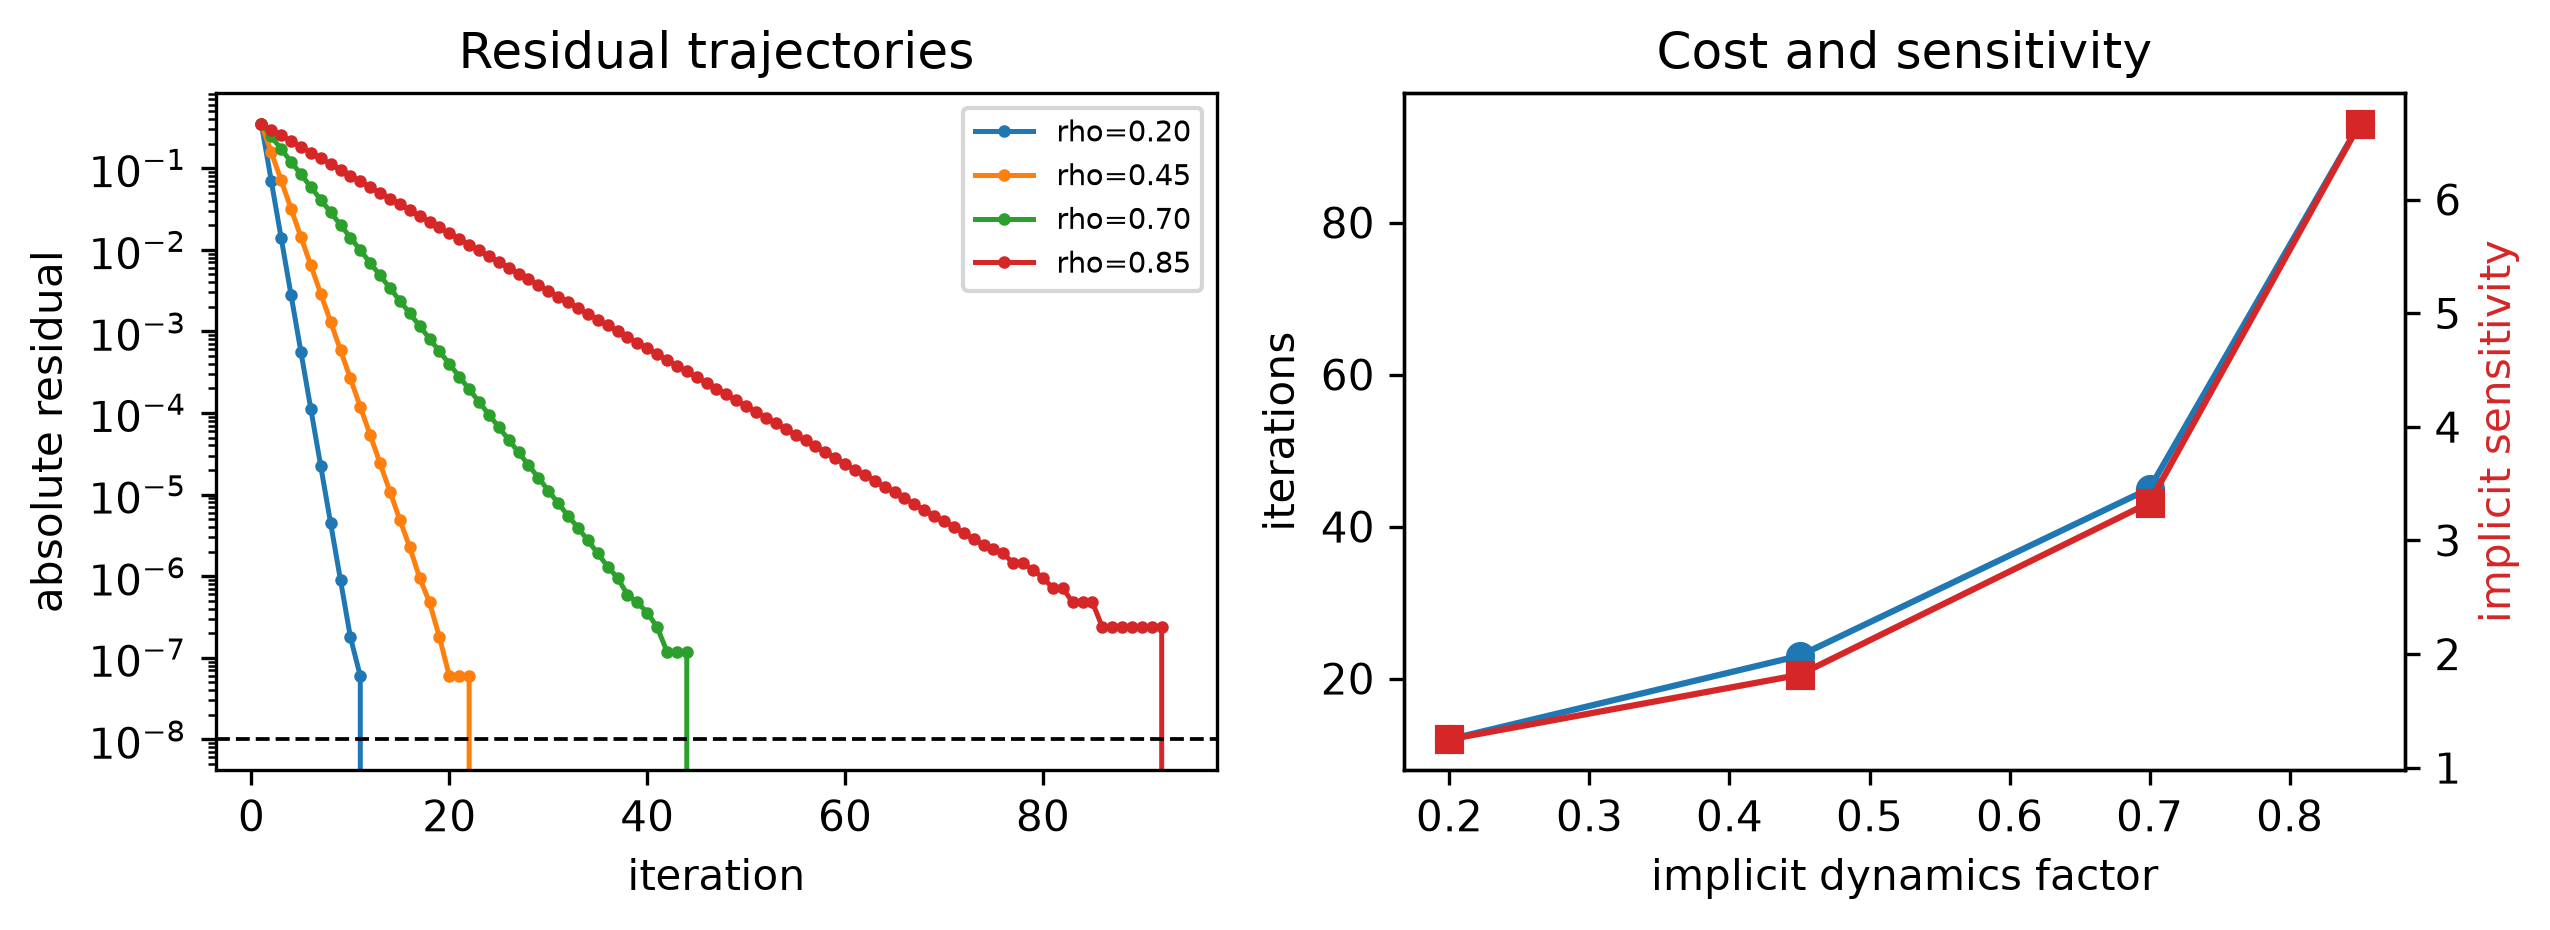

In [11]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('implicit dynamics factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the implicit dynamics factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | trajectory error, terminal fixed-point residual, and conservation error |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | time-step shape, initial condition, and integration consistency |
| Scale sweep | Change one of time horizon, step count, state dimension, and stiffness at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How are the analytic homotopy pairs constructed? | [Dataset-Backed Equilibrium Labs](https://jseluis.github.io/silva-networks/learn/frontier-dataset-labs/#affine-homotopy-pairs) |
| How does the residual flow retain the SILVA fixed point? | [Recent Equilibrium Families](https://jseluis.github.io/silva-networks/learn/frontier-equilibrium-families/#silva-homotopy-equilibrium) |
| Which homotopy dataset objects are public? | [Recent Dataset API](https://jseluis.github.io/silva-networks/api/frontier_data/) |
